<h1 align="center" id="top"><u>Pokemon classification</u></h1>
<h3 align="center"><u>Clément MOLLY-MITTON | Diane VERBECQ</u></h3>

# Table of Contents
***
1. [Import](#import)

## Import
***

In [1]:
from pathlib import Path

from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

from background import remove_background
from config import BackgroundMethod, ExtractMethod
from display import show_confusion_matrix, show_image
from pipeline import evaluate_all_methods, split_dataset
from preprocessing import preprocessing
from utils import build_dataframe, load_image

Let's now load the dataset using pandas (mapping the images path with their respective pokemon)

In [2]:
data_dir = Path.cwd().resolve().parents[0] / "data" / "fanart-dataset"

fanart_df = build_dataframe(data_dir)

print("\nTotal images:", len(fanart_df))
print("Total Pokémon:", fanart_df["pokemon"].nunique())
print("\n20 most present pokemon:")
print(fanart_df["pokemon"].value_counts().head(20))


Total images: 8775
Total Pokémon: 888

20 most present pokemon:
pokemon
gengar        60
leafeon       53
umbreon       52
garchomp      51
sceptile      51
sylveon       49
arcanine      48
rayquaza      48
bulbasaur     47
eevee         47
gardevoir     46
suicune       46
vaporeon      44
chandelure    43
greninja      43
zoroark       43
lugia         42
blastoise     41
mudkip        41
rowlet        41
Name: count, dtype: int64


Now let's filter a bit our dataset so that we only keep pokemons with a sufficient number of images

In [3]:
MIN_PER_CLASS = 15
counts = fanart_df["pokemon"].value_counts()
keep = counts[counts >= MIN_PER_CLASS].index
fanart_df_filtered = fanart_df[fanart_df["pokemon"].isin(keep)].reset_index(drop=True)

print("After filter:")
print("Total images:", len(fanart_df_filtered))
print("Total Pokémon:", fanart_df_filtered["pokemon"].nunique())
print(fanart_df_filtered["pokemon"].value_counts().head(10))

After filter:
Total images: 5007
Total Pokémon: 186
pokemon
gengar       60
leafeon      53
umbreon      52
garchomp     51
sceptile     51
sylveon      49
arcanine     48
rayquaza     48
bulbasaur    47
eevee        47
Name: count, dtype: int64


In [4]:
fanart_df_filtered

,path,pokemon
0,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,absol
1,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,absol
2,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,absol
3,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,absol
4,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,absol
...,...,...
5002,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,zorua
5003,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,zorua
5004,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,zorua
5005,C:\Bureau\CS\partie2\VISUAL\projet\Pokemon_Cla...,zorua


Let's encode now the label using sklearn's LabelEncoder and split the dataframe into a dataset of path and labels

In [5]:
top10 = fanart_df_filtered["pokemon"].value_counts().head(10).index
fanart_df_filtered = (
    fanart_df_filtered[fanart_df_filtered["pokemon"].isin(top10)].copy().reset_index(drop=True)
)
print(fanart_df_filtered["pokemon"].value_counts())

pokemon
gengar       60
leafeon      53
umbreon      52
garchomp     51
sceptile     51
sylveon      49
arcanine     48
rayquaza     48
bulbasaur    47
eevee        47
Name: count, dtype: int64


In [6]:
dataset = fanart_df_filtered["path"]
label = fanart_df_filtered["pokemon"]

label_encoder = LabelEncoder()
label = label_encoder.fit_transform(label)

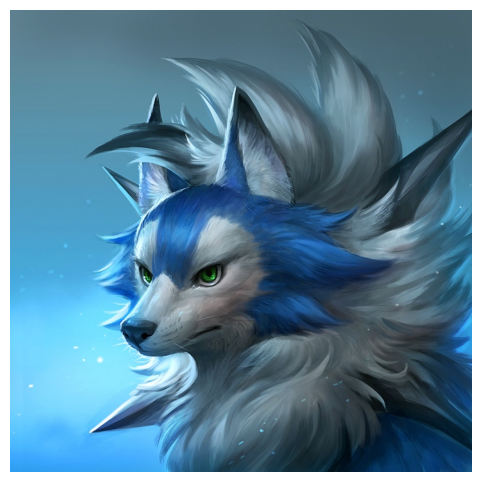

In [7]:
im = load_image(Path(dataset[3]))
show_image(im)

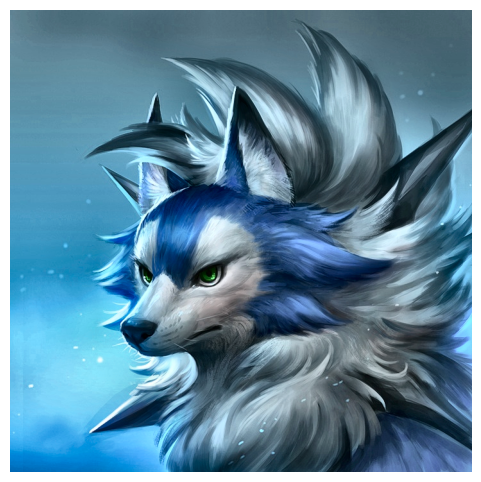

In [8]:
new_im = preprocessing(im)
show_image(new_im)

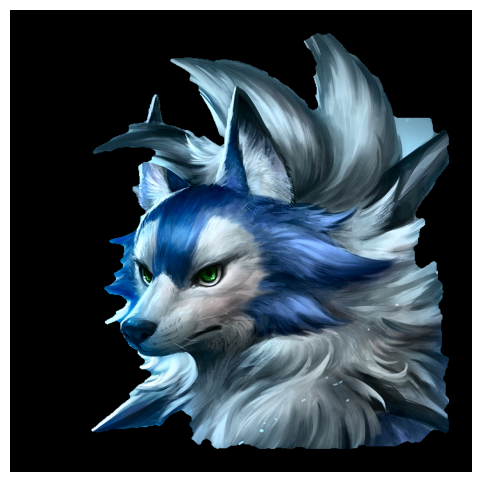

In [9]:
only_pokemon = remove_background(new_im, method=BackgroundMethod.GRABCUT)
show_image(only_pokemon)

In [10]:
X_train, X_test, y_train, y_test = split_dataset(
    dataset,
    label,
    ExtractMethod.SIFT,
    BackgroundMethod.NONE,
)

[INFO] : Dataset split done ! (train=404, test=102)


Extracting descriptors for train:   0%|                    | 0/404 

Extracting descriptors for test:   0%|                    | 0/102 

[INFO] : Starting BoVW training...
[INFO] : BoVW training finished ! 
[INFO] : Starting BoVW encoding...
[INFO] : BoVW encoding done ! 


In [11]:
clf = LinearSVC(C=1.0, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

              precision    recall  f1-score   support

    arcanine       0.43      0.60      0.50        10
   bulbasaur       0.20      0.11      0.14         9
       eevee       0.22      0.22      0.22         9
    garchomp       0.33      0.30      0.32        10
      gengar       0.00      0.00      0.00        12
     leafeon       0.29      0.36      0.32        11
    rayquaza       0.43      0.30      0.35        10
    sceptile       0.00      0.00      0.00        10
     sylveon       0.43      0.30      0.35        10
     umbreon       0.42      0.73      0.53        11

    accuracy                           0.29       102
   macro avg       0.27      0.29      0.27       102
weighted avg       0.27      0.29      0.27       102



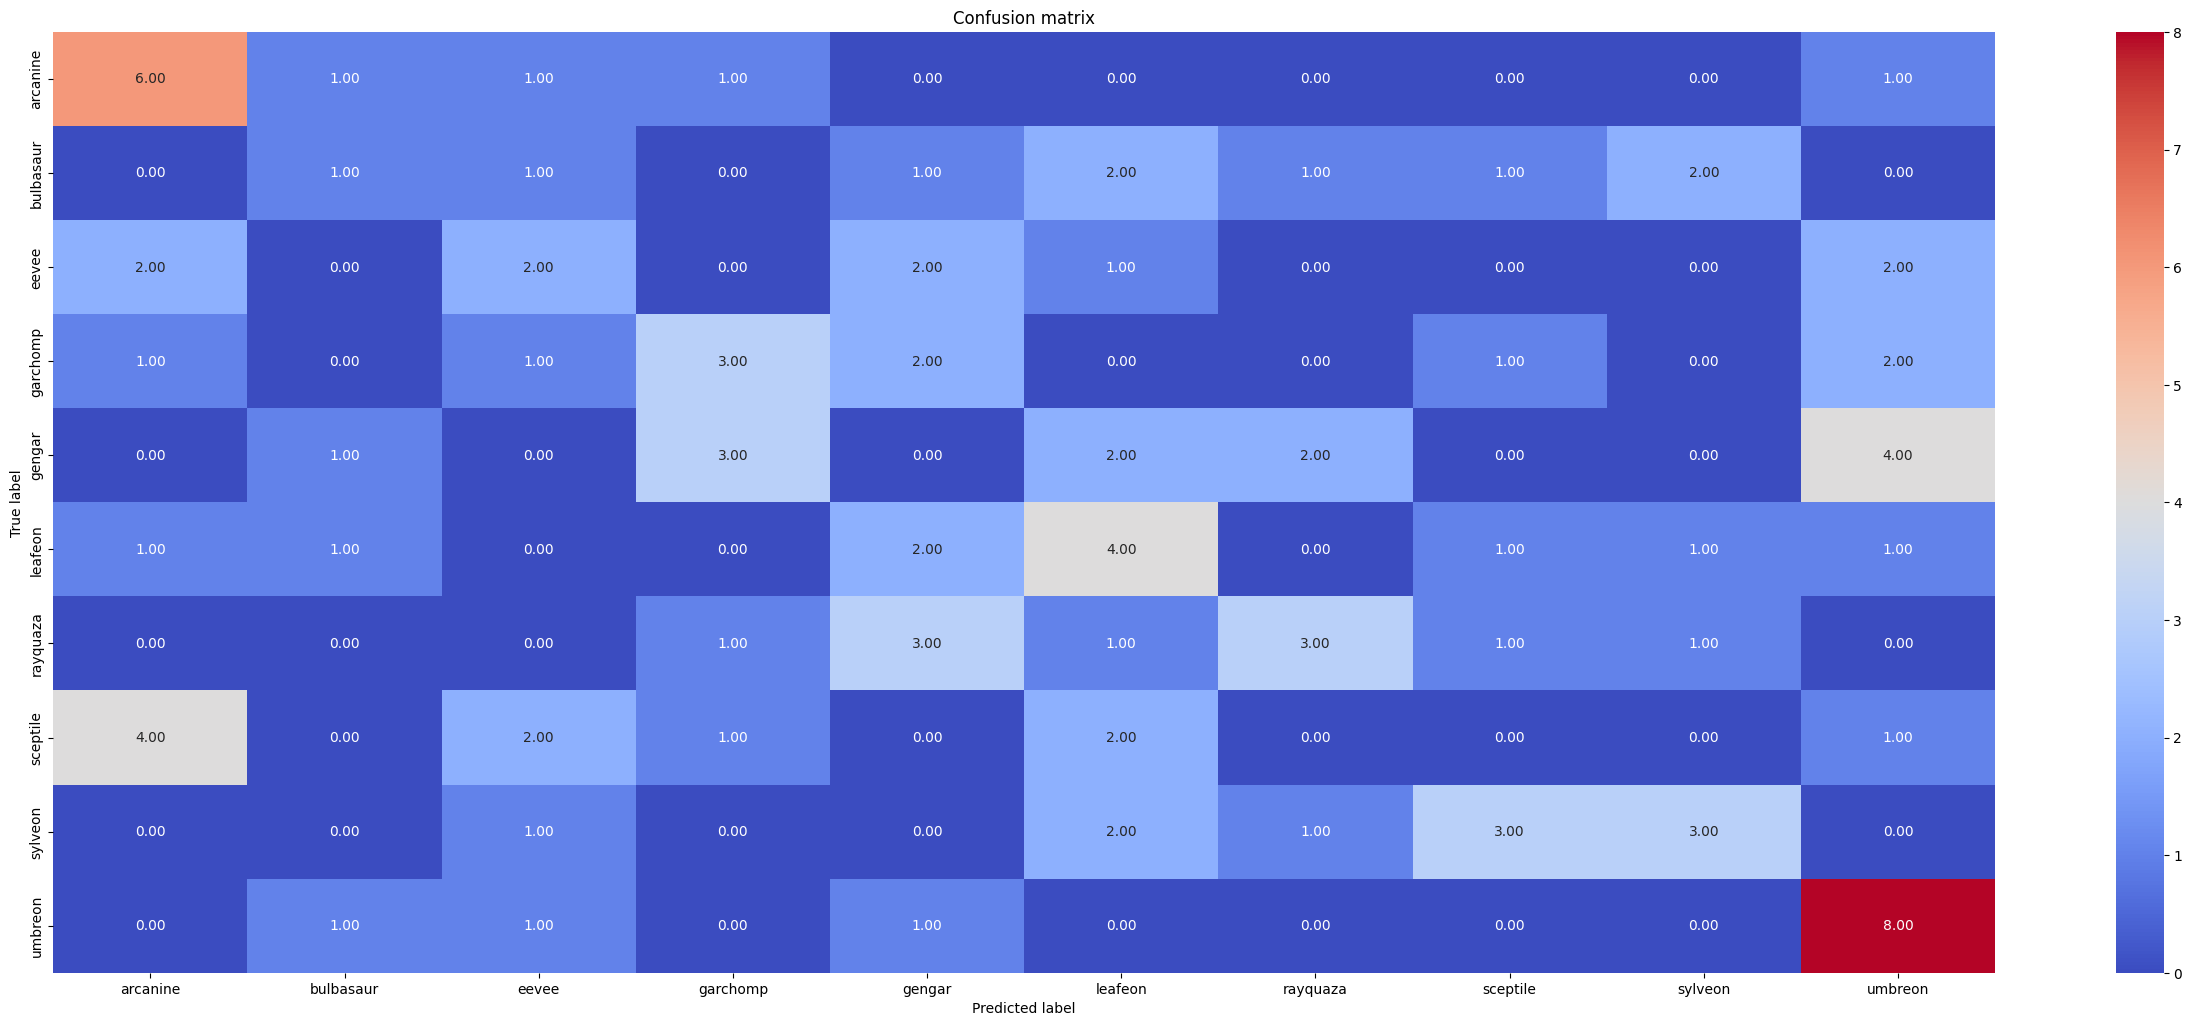

In [12]:
show_confusion_matrix(y_test, y_pred, label_encoder.classes_, "Confusion matrix")

Now let's test each possibility and compare the results

In [13]:
models = [
    (LinearSVC, {"C": 1.0, "random_state": 42}),
]
results = evaluate_all_methods(dataset, label, label_encoder, models)
results

Evaluation:   0%|                              | 0/4 

Extracting descriptors for train:   0%|                    | 0/404 

Extracting descriptors for test:   0%|                    | 0/102 

Extracting descriptors for train:   0%|                    | 0/404 

Extracting descriptors for test:   0%|                    | 0/102 

Extracting descriptors for train:   0%|                    | 0/404 

Extracting descriptors for test:   0%|                    | 0/102 

Extracting descriptors for train:   0%|                    | 0/404 

Extracting descriptors for test:   0%|                    | 0/102 

,model,extract_method,background_method,accuracy,precision_macro,recall_macro,f1_macro,classification_report,train_time_sec
0,LinearSVC,SIFT,NONE,0.294118,0.274804,0.292424,0.274008,precision recall f1-score ...,0.075614
1,LinearSVC,SIFT,GRABCUT,0.343137,0.313649,0.342727,0.320889,precision recall f1-score ...,0.065087
2,LinearSVC,ORB,NONE,0.254902,0.231457,0.255354,0.235421,precision recall f1-score ...,0.097939
3,LinearSVC,ORB,GRABCUT,0.264706,0.270271,0.264747,0.248915,precision recall f1-score ...,0.084281
